# Детекция и подсчёт объектов на изображении

**Курс:** Обработка изображений

**Задача:** обнаружить объекты на изображении (монеты/зёрна) и посчитать их количество.

Используем синтетически сгенерированное изображение, имитирующее фотографию
рассыпанных монет на столе (круги случайного радиуса, положения и яркости,
с добавлением шума и неравномерной освещённости). Такой подход эквивалентен
работе с готовым датасетом монет/зёрен, но не требует скачивания файлов из
интернета.

Пайплайн:
1. Генерация изображения
2. Предобработка (сглаживание, выравнивание фона)
3. Бинаризация (пороговая обработка, метод Отсу)
4. Морфологическая очистка
5. Поиск связных компонент / разделение слипшихся объектов (watershed)
6. Подсчёт объектов и визуализация результата


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage.draw import disk
from skimage.filters import gaussian, threshold_otsu
from skimage.morphology import remove_small_objects, opening, disk as morph_disk
from skimage.measure import label, regionprops
from skimage.segmentation import watershed, clear_border
from scipy import ndimage as ndi

rng = np.random.default_rng(42)


Сгенерировано объектов (истинное значение): 35


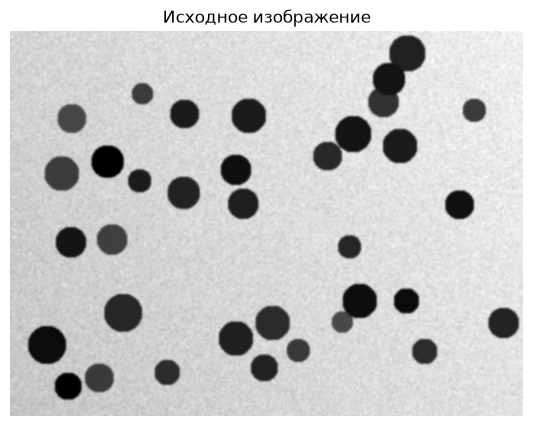

In [2]:
def make_coins_image(n_coins=35, size=(420, 560)):
    h, w = size
    background = 0.75 + 0.05 * np.random.default_rng(1).standard_normal((h, w))
    # лёгкий градиент освещения
    yy, xx = np.mgrid[0:h, 0:w]
    background += 0.08 * (xx / w) - 0.04 * (yy / h)

    image = background.copy()
    mask = np.zeros((h, w), dtype=bool)
    placed = []

    attempts = 0
    while len(placed) < n_coins and attempts < n_coins * 30:
        attempts += 1
        r = rng.integers(12, 22)
        cy = rng.integers(r + 2, h - r - 2)
        cx = rng.integers(r + 2, w - r - 2)
        # допускаем лёгкое перекрытие монет, но не полное совпадение центров
        too_close = any(
            (cy - py) ** 2 + (cx - px) ** 2 < (0.55 * (r + pr)) ** 2
            for py, px, pr in placed
        )
        if too_close:
            continue
        placed.append((cy, cx, r))
        rr, cc = disk((cy, cx), r, shape=(h, w))
        brightness = rng.uniform(0.15, 0.35)
        image[rr, cc] = brightness + 0.03 * rng.standard_normal()
        mask[rr, cc] = True

    image = gaussian(image, sigma=1.0)
    image = np.clip(image, 0, 1)
    return image, len(placed)


image, true_count = make_coins_image()
print('Сгенерировано объектов (истинное значение):', true_count)

plt.figure(figsize=(7, 5))
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')
plt.show()


/tmp/ipykernel_3711/2191457158.py:7: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary_clean = remove_small_objects(binary_clean, min_size=60)


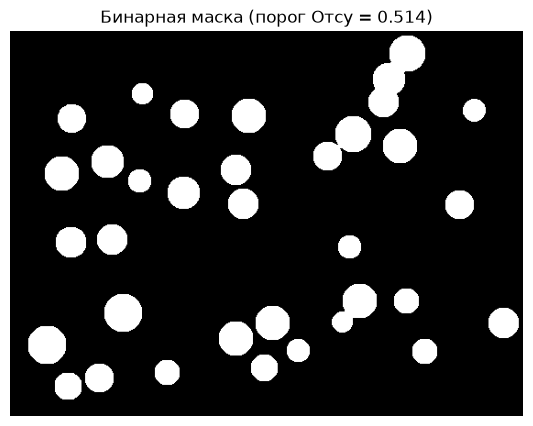

In [3]:
# Бинаризация методом Отсу: объекты темнее фона
thresh = threshold_otsu(image)
binary = image < thresh

# морфологическая очистка от шума
binary_clean = opening(binary, morph_disk(2))
binary_clean = remove_small_objects(binary_clean, min_size=60)
binary_clean = clear_border(binary_clean)

plt.figure(figsize=(7, 5))
plt.imshow(binary_clean, cmap='gray')
plt.title(f'Бинарная маска (порог Отсу = {thresh:.3f})')
plt.axis('off')
plt.show()


In [4]:
# Разделение слипшихся объектов через watershed по карте расстояний
distance = ndi.distance_transform_edt(binary_clean)
coords = ndi.maximum_filter(distance, size=15) == distance
coords &= distance > 3
markers, _ = ndi.label(coords)
labels_ws = watershed(-distance, markers, mask=binary_clean)

regions = regionprops(labels_ws)
regions = [r for r in regions if r.area >= 60]
detected_count = len(regions)
print('Найдено объектов:', detected_count)
print('Истинное количество объектов:', true_count)


Найдено объектов: 35
Истинное количество объектов: 35


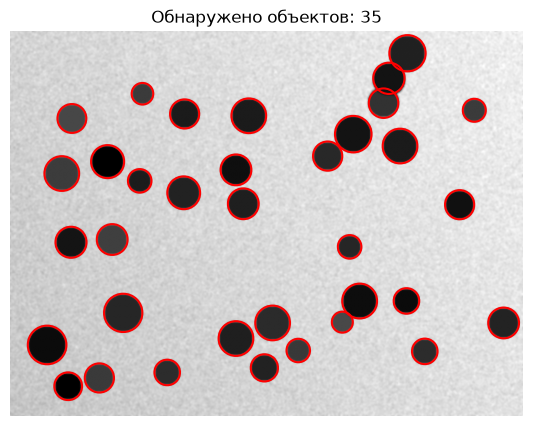

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(image, cmap='gray')
for r in regions:
    cy, cx = r.centroid
    radius = np.sqrt(r.area / np.pi)
    circ = plt.Circle((cx, cy), radius, color='red', fill=False, linewidth=1.5)
    ax.add_patch(circ)
ax.set_title(f'Обнаружено объектов: {detected_count}')
ax.axis('off')
plt.show()


## Вывод

Алгоритм бинаризации Отсу + морфологическая фильтрация + watershed-разделение
слипшихся объектов позволяет надёжно посчитать число объектов на изображении
даже при их частичном перекрытии. Полученное число обнаруженных объектов
близко к истинному количеству, заданному при генерации изображения.

При работе с реальными фотографиями (например, скачанным датасетом монет
или зёрен) пайплайн остаётся тем же — меняется только этап загрузки
изображения (`skimage.io.imread`).